# 19. Learning from history — frozen models (research question 3)
*This time is different?* For each crisis, 5 LSTMs are trained **only on the data before the crisis** and never updated ('frozen'); they forecast the whole crisis window. Their QLIKE is divided by HAR's QLIKE in the same window: **above 1 = worse than HAR**.

**H3** (written before the results, the 'Minsky test'): the GFC model, which had seen only the calm 2003–07 boom, suffers most; then COVID; the Irish-crisis model (which had already seen the GFC) least.

* **Needs:** the forecasts in `work/` (and `work/model_data.csv` if you re-train). **Makes:** nothing new.

*Simple notebook series of the project 'This Time Is Different?'. Prepared with AI assistance (declared in `notes/ai_use.md`); a study notebook, not dissertation text.*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
folder = '/content/drive/MyDrive/DataSets/ThisTimeIsDifferent/'

import warnings
warnings.filterwarnings('ignore')     # hide warning messages

## The saved results
Training the 15 frozen models takes about 5–10 minutes on Colab; set `run_frozen = True` further below to do it. First the saved table:

In [2]:
from pandas import read_csv
frozen_table = read_csv(folder + 'results/evaluation_frozen.csv', index_col=0)
frozen_table[['trained_until', 'days', 'ratio_frozen_to_HAR', 'ratio_refitted_to_HAR']].round(2)

,trained_until,days,ratio_frozen_to_HAR,ratio_refitted_to_HAR
crisis,,,,
Global Financial Crisis,2007-08-08,402,4.26,1.51
Irish sovereign debt crisis,2010-04-22,574,1.33,1.20
COVID-19,2020-02-18,92,0.74,0.74


* **frozen** = trained only before the crisis; **refitted** = the normal model of notebook 17 (re-trained every year).
* GFC: the frozen model was **4.3 times** worse than HAR. COVID: 0.74 — **better** than HAR, although it had never seen a pandemic.

In [3]:
ranking = frozen_table['ratio_frozen_to_HAR'].sort_values(ascending=False)
print('observed ranking (worst first):', list(ranking.index))
print('expected ranking (H3)         :', ['Global Financial Crisis', 'COVID-19', 'Irish sovereign debt crisis'])
if list(ranking.index) == ['Global Financial Crisis', 'COVID-19', 'Irish sovereign debt crisis']:
    print('H3 supported')
else:
    print('H3 NOT supported as ranked (but the GFC is the worst, as expected)')

observed ranking (worst first): ['Global Financial Crisis', 'Irish sovereign debt crisis', 'COVID-19']
expected ranking (H3)         : ['Global Financial Crisis', 'COVID-19', 'Irish sovereign debt crisis']
H3 NOT supported as ranked (but the GFC is the worst, as expected)


<Axes: title={'center': 'LSTM QLIKE / HAR QLIKE in each crisis (1 = as good as HAR)'}, xlabel='crisis'>

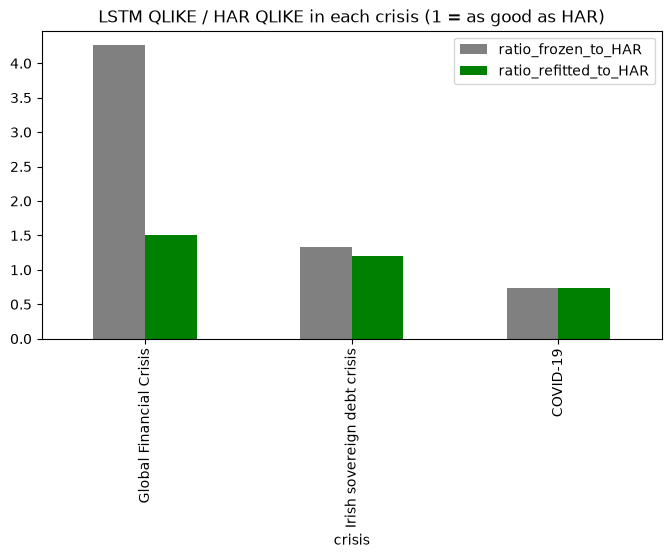

In [4]:
frozen_table[['ratio_frozen_to_HAR', 'ratio_refitted_to_HAR']].plot(kind='bar', figsize=(8, 4), color=['grey', 'green'], title='LSTM QLIKE / HAR QLIKE in each crisis (1 = as good as HAR)')

## Optional: train the frozen models here
The same functions as notebook 17, with a different last training day: the day before each window starts.

In [5]:
run_frozen = False

The data, the LSTM blueprint and the two functions — exactly as in notebook 17:

In [6]:
import torch
from numpy import log
model_data = read_csv(folder + 'work/model_data.csv', index_col=0, parse_dates=True)
x = model_data[['ret', 'log_r2', 'us_ret', 'log_us_r2', 'euro_ret', 'log_euro_r2']]
y = model_data['log_rv5_fwd']
har = read_csv(folder + 'work/har_forecasts.csv', index_col=0, parse_dates=True)
dataset = read_csv(folder + 'work/dataset.csv', index_col=0, parse_dates=True)

In [7]:
from torch import nn
torch.set_num_threads(2)


class LSTMVol(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.2)   # 6 inputs, 64 units, 2 layers
        self.drop = nn.Dropout(0.2)
        self.head = nn.Linear(64, 1)                                                # one number out

    def forward(self, x):
        out, _ = self.lstm(x)                  # read the 22 days, one after the other
        last_day = out[:, -1]                  # the memory after the last day
        return self.head(self.drop(last_day)).squeeze(-1)

In [8]:
from pandas import Timestamp, DateOffset, Timedelta, Series
from numpy import array, exp, random


def train_lstm(train_end, seed):
    """Notebook 15 in one function: train one LSTM on the data up to train_end."""
    # the three groups of days (notebook 14)
    train_end = Timestamp(train_end)
    val_start = train_end - DateOffset(years=1) + Timedelta(days=1)
    fit_days = y.iloc[21:].loc[:val_start - Timedelta(days=1)].dropna().index[:-5]
    val_days = y.loc[val_start:train_end].dropna().index[:-5]
    # scaling
    mean = x.loc[:fit_days[-1]].mean()
    std = x.loc[:fit_days[-1]].std()
    x_scaled = (x - mean) / std
    y_mean = y.loc[fit_days].mean()
    y_std = y.loc[fit_days].std()
    y_scaled = (y - y_mean) / y_std
    # windows
    x_fit = []
    for day in fit_days:
        position = x.index.get_loc(day)
        x_fit.append(x_scaled.values[position - 21:position + 1])
    x_val = []
    for day in val_days:
        position = x.index.get_loc(day)
        x_val.append(x_scaled.values[position - 21:position + 1])
    x_fit = torch.tensor(array(x_fit, dtype='float32'))
    y_fit = torch.tensor(array(y_scaled.loc[fit_days], dtype='float32'))
    x_val = torch.tensor(array(x_val, dtype='float32'))
    y_val = torch.tensor(array(y_scaled.loc[val_days], dtype='float32'))
    # building
    torch.manual_seed(seed)
    random.seed(seed)
    model = LSTMVol()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_function = nn.MSELoss()
    # training with early stopping
    best_val_loss = 1000000.0
    wait = 0
    for epoch in range(1, 201):
        model.train()
        order = torch.randperm(len(x_fit))
        for start in range(0, len(x_fit), 64):
            batch = order[start:start + 64]
            optimizer.zero_grad()
            loss_function(model(x_fit[batch]), y_fit[batch]).backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            val_loss = loss_function(model(x_val), y_val).item()
        if val_loss < best_val_loss - 0.0001:
            best_val_loss = val_loss
            best_weights = {}
            for name, value in model.state_dict().items():
                best_weights[name] = value.clone()
            wait = 0
        else:
            wait = wait + 1
            if wait >= 15:
                break
    model.load_state_dict(best_weights)
    model.eval()
    # smearing factor on the validation days
    with torch.no_grad():
        val_pred_log = model(x_val).numpy() * y_std + y_mean
    smear = exp(y.loc[val_days].values - val_pred_log).mean()
    return {'model': model, 'mean': mean, 'std': std, 'y_mean': y_mean, 'y_std': y_std, 'smear': smear}


def forecast_lstm(m, days):
    """Testing: forecasts (variance) of a trained model for the given days."""
    x_scaled = (x - m['mean']) / m['std']
    x_days = []
    for day in days:
        position = x.index.get_loc(day)
        x_days.append(x_scaled.values[position - 21:position + 1])
    with torch.no_grad():
        pred_scaled = m['model'](torch.tensor(array(x_days, dtype='float32'))).numpy()
    return Series(exp(pred_scaled * m['y_std'] + m['y_mean']) * m['smear'], index=days)

The loop: for each crisis, 5 frozen models, their average forecast, and the ratio to HAR.

In [9]:
if run_frozen:
    last_training_day = {'Global Financial Crisis': '2007-08-08',
                         'Irish sovereign debt crisis': '2010-04-22',
                         'COVID-19': '2020-02-18'}
    for crisis in last_training_day:
        days = har.index[dataset.loc[har.index, 'window'] == crisis]
        frozen = 0
        for seed in [1, 2, 3, 4, 5]:
            m = train_lstm(last_training_day[crisis], seed)
            frozen = frozen + forecast_lstm(m, days) / 5            # the average of 5 seeds
        realised = dataset.loc[days, 'rv5_fwd']
        ratio = realised / frozen
        q_frozen = (ratio - log(ratio) - 1).mean()
        ratio = realised / har.loc[days, 'HAR']
        q_har = (ratio - log(ratio) - 1).mean()
        print(crisis, '| frozen LSTM / HAR =', round(q_frozen / q_har, 2))